In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m
import matplotlib.pyplot as plt

#### Scanning duration

0.7586758675867586
1.249930915240466


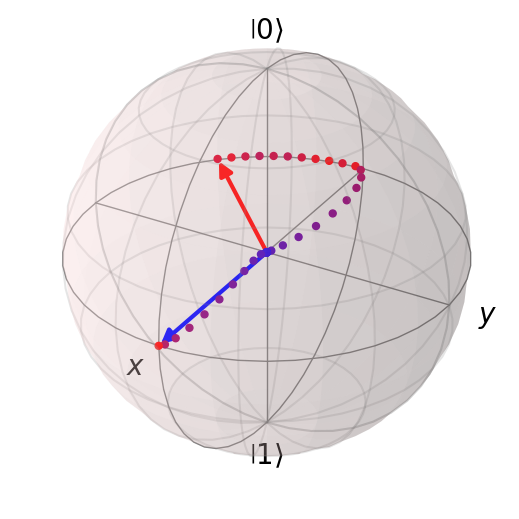

In [ ]:
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 10

indices = [10,11]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

shifts = np.linspace(0, 1, 10000)
for shift in shifts:
    duration = (pi/(4*dR))*shift

    mom_dependent_free_evolution = PulseSequence()

    up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)

    mom_dependent_free_evolution.add_pulses([
                                            # up_pulse, freevolve2, up_pulse, freevolve2,
                                                down_pulse, freevolve, down_pulse, freevolve,
                                                ])

    wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

    phase = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
    if phase < 1.2501 and phase > 1.2499:
        print(shift)
        print(phase)
        break

plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)



#### Check phase for a  specific duration

1.7542948574977972
0.0012269989844825588


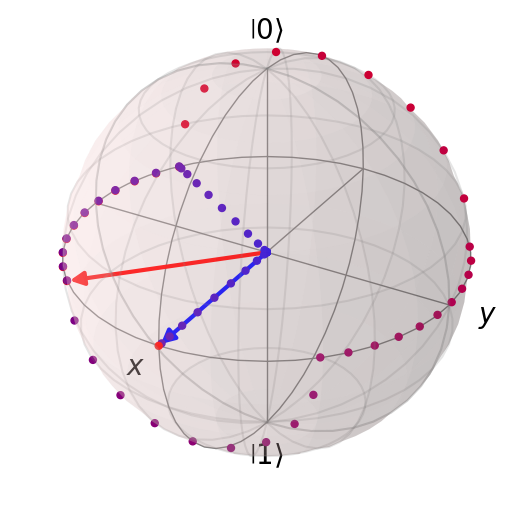

In [90]:
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e8
rabi_time = 2*pi/rabi_freq

time_steps = 10

indices = [11,12]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

shift = 1

duration = (pi/(4*dR))*shift

mom_dependent_free_evolution = PulseSequence()

up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


mom_dependent_free_evolution.add_pulses([
                                        up_pulse, freevolve, up_pulse, freevolve,
                                            down_pulse, freevolve, down_pulse, freevolve,
                                            ])


wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

phase = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi

print(phase)

print(rabi_time/duration)

plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)


#### Plotting phase against free duration

##### Even

1.2501600605541614


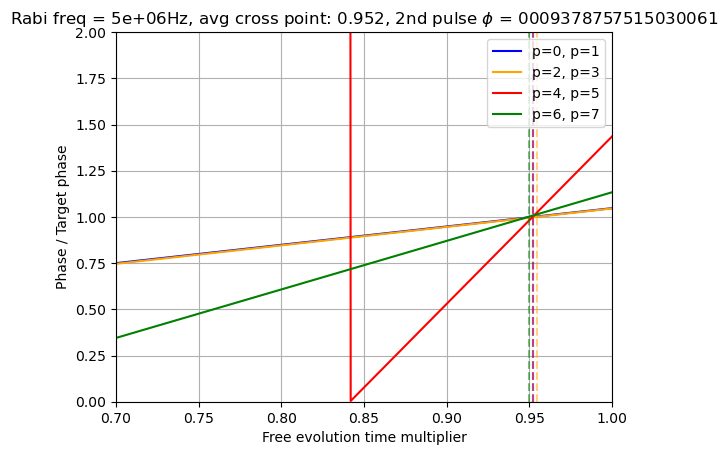

In [7]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state[10] = 1
initial_state[11] = 1
initial_state[12] = 1
initial_state[13] = 1
initial_state[14] = 1
initial_state[15] = 1
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

shifts = np.linspace(0.7,1,500)
phases = np.zeros(len(shifts))
phases2 = np.zeros(len(shifts))
phases3 = np.zeros(len(shifts))
phases4 = np.zeros(len(shifts))

for i, shift in enumerate(shifts):
    duration = (pi/(4*dR))*shift

    mom_dependent_free_evolution = PulseSequence()

    up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0.0009378757515030061*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


    mom_dependent_free_evolution.add_pulses([
                                            # up_pulse, freevolve, up_pulse, freevolve,
                                                down_pulse, freevolve, down_pulse2, freevolve,
                                                ])


    wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

    phases[i] = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
    phases2[i] = ((np.angle(wave_func[-1,indices2[1]]) - np.angle(wave_func[-1,indices2[0]])) % (2*np.pi))/pi
    phases3[i] = ((np.angle(wave_func[-1,indices3[1]]) - np.angle(wave_func[-1,indices3[0]])) % (2*np.pi))/pi
    phases4[i] = ((np.angle(wave_func[-1,indices4[1]]) - np.angle(wave_func[-1,indices4[0]])) % (2*np.pi))/pi
    

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases) - 0.25))
cross2 = np.argmin(np.abs(np.array(phases2) - 1.25))
cross3 = np.argmin(np.abs(np.array(phases3) - 0.25))
cross4 = np.argmin(np.abs(np.array(phases4) - 1.25))
avg_cross = np.mean([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])


x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]
x4 = [shifts[cross4], shifts[cross4]]
y1 = [0, 2]

print(phases2[cross2])

phases /= 0.25
phases2 /= 1.25
phases3 /= 0.25
phases4 /= 1.25

plt.plot(shifts, phases, c = 'blue', label = 'p=0, p=1')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'orange', label = 'p=2, p=3')
plt.plot(x2,y1, c = 'orange', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'red', label = 'p=4, p=5')
plt.plot(x3,y1, c = 'red', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases4, c = 'green', label = 'p=6, p=7')
plt.plot(x4,y1, c = 'green', linestyle = '--', alpha = 0.5)
plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_cross:.3f}, 2nd pulse $\phi$ = 0009378757515030061')
plt.show()


##### Odd

0.13569228491236332


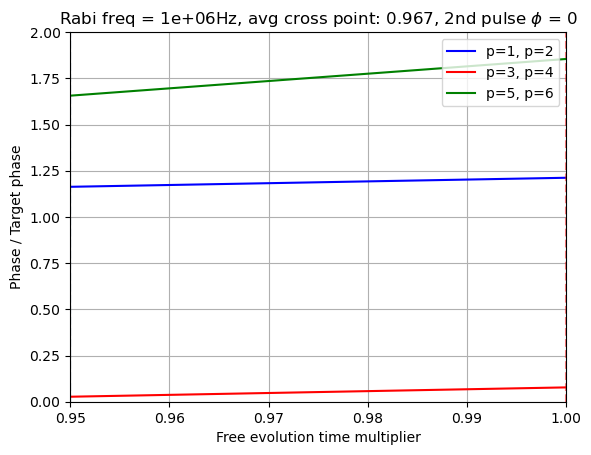

In [18]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [9,10]
indices2 = [11,12]
indices3 = [13,14]


initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state[10] = 1
initial_state[11] = 1
initial_state[12] = 1
initial_state[13] = 1
initial_state[14] = 1
initial_state[15] = 1
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

shifts = np.linspace(0.95,1,2000)
phases = np.zeros(len(shifts))
phases2 = np.zeros(len(shifts))
phases3 = np.zeros(len(shifts))
phases4 = np.zeros(len(shifts))

for i, shift in enumerate(shifts):
    duration = (pi/(4*dR))*shift

    mom_dependent_free_evolution = PulseSequence()

    up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


    mom_dependent_free_evolution.add_pulses([
                                            up_pulse, freevolve, up_pulse, freevolve,
                                                # down_pulse, freevolve, down_pulse, freevolve,
                                                ])


    wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

    phases[i] = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
    phases2[i] = ((np.angle(wave_func[-1,indices2[1]]) - np.angle(wave_func[-1,indices2[0]])) % (2*np.pi))/pi
    phases3[i] = ((np.angle(wave_func[-1,indices3[1]]) - np.angle(wave_func[-1,indices3[0]])) % (2*np.pi))/pi
    

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases) - 0.75))
cross2 = np.argmin(np.abs(np.array(phases2) - 1.75))
cross3 = np.argmin(np.abs(np.array(phases3) - 0.75))

avg_cross = np.mean([shifts[cross],shifts[cross2],shifts[cross3]])


x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]

y1 = [0, 2]

print(phases2[cross2])

phases /= 0.75
phases2 /= 1.75
phases3 /= 0.75
phases4 /= 1.75

plt.plot(shifts, phases, c = 'blue', label = 'p=1, p=2')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'red', label = 'p=3, p=4')
plt.plot(x2,y1, c = 'red', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'green', label = 'p=5, p=6')
plt.plot(x3,y1, c = 'green', linestyle = '--', alpha = 0.5)

plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_cross:.3f}, 2nd pulse $\phi$ = 0')
plt.show()


#### Adjusted free time against rabi frequency

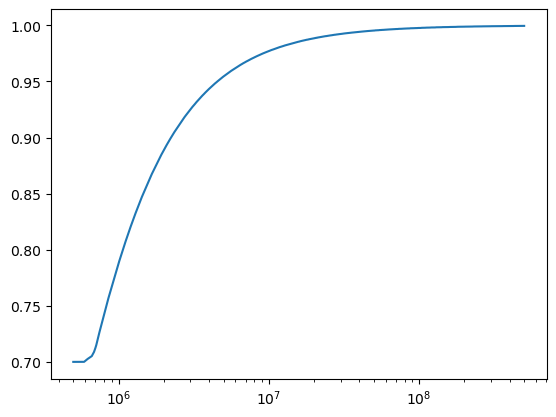

In [27]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

# rabi_freq = 2*pi*1e8
# rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state[10] = 1
initial_state[11] = 1
initial_state[12] = 1
initial_state[13] = 1
initial_state[14] = 1
initial_state[15] = 1
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# rabis = 2*pi*np.linspace(1e6, 1e7, 50)
rabis = 5*2*pi*np.logspace(5, 8, 1000)
avg_crossings = np.zeros(len(rabis))

for j, rabi_freq in enumerate(rabis):

    shifts = np.linspace(0.7,1,2000)
    phases = np.zeros(len(shifts))
    phases2 = np.zeros(len(shifts))
    phases3 = np.zeros(len(shifts))
    phases4 = np.zeros(len(shifts))

    for i, shift in enumerate(shifts):
        duration = (pi/(4*dR))*shift

        rabi_time = 2*pi/rabi_freq

        mom_dependent_free_evolution = PulseSequence()

        up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                # up_pulse, freevolve, up_pulse, freevolve,
                                                    down_pulse, freevolve, down_pulse, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[i] = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
        phases2[i] = ((np.angle(wave_func[-1,indices2[1]]) - np.angle(wave_func[-1,indices2[0]])) % (2*np.pi))/pi
        phases3[i] = ((np.angle(wave_func[-1,indices3[1]]) - np.angle(wave_func[-1,indices3[0]])) % (2*np.pi))/pi
        phases4[i] = ((np.angle(wave_func[-1,indices4[1]]) - np.angle(wave_func[-1,indices4[0]])) % (2*np.pi))/pi
        

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases) - 0.25))
    cross2 = np.argmin(np.abs(np.array(phases2) - 1.25))
    cross3 = np.argmin(np.abs(np.array(phases3) - 0.25))
    cross4 = np.argmin(np.abs(np.array(phases4) - 1.25))
    avg_crossings[j] = np.mean([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])


plt.semilogx(rabis/(2*pi), avg_crossings)




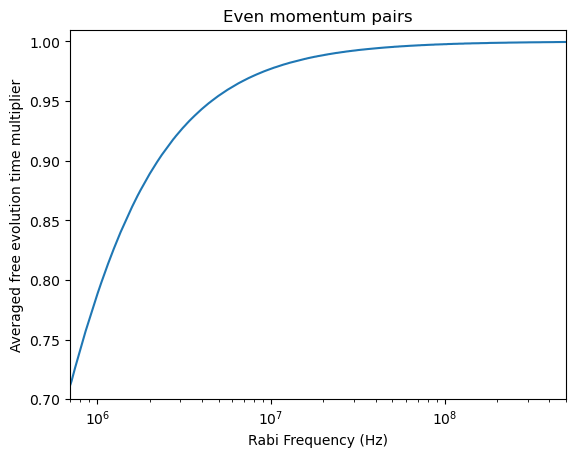

In [35]:
plt.semilogx(rabis/(2*pi), avg_crossings)
plt.ylabel('Averaged free evolution time multiplier')
plt.xlabel('Rabi Frequency (Hz)')
plt.title('Even momentum pairs')
plt.xlim(7e5, 5e8)
plt.ylim(0.7,1.01)
plt.show()

In [28]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

# rabi_freq = 2*pi*1e8
# rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state[10] = 1
initial_state[11] = 1
initial_state[12] = 1
initial_state[13] = 1
initial_state[14] = 1
initial_state[15] = 1
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

rabis1 = 2*pi*np.linspace(0, 1e7, 1000)
# rabis = 2*pi*np.logspace(5, 9, 100)
avg_crossings1 = np.zeros(len(rabis1))

for j, rabi_freq in enumerate(rabis1):

    shifts = np.linspace(0.7,1,2000)
    phases = np.zeros(len(shifts))
    phases2 = np.zeros(len(shifts))
    phases3 = np.zeros(len(shifts))
    phases4 = np.zeros(len(shifts))

    for i, shift in enumerate(shifts):
        duration = (pi/(4*dR))*shift

        rabi_time = 2*pi/rabi_freq

        mom_dependent_free_evolution = PulseSequence()

        up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                # up_pulse, freevolve, up_pulse, freevolve,
                                                    down_pulse, freevolve, down_pulse, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[i] = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
        phases2[i] = ((np.angle(wave_func[-1,indices2[1]]) - np.angle(wave_func[-1,indices2[0]])) % (2*np.pi))/pi
        phases3[i] = ((np.angle(wave_func[-1,indices3[1]]) - np.angle(wave_func[-1,indices3[0]])) % (2*np.pi))/pi
        phases4[i] = ((np.angle(wave_func[-1,indices4[1]]) - np.angle(wave_func[-1,indices4[0]])) % (2*np.pi))/pi
        

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases) - 0.25))
    cross2 = np.argmin(np.abs(np.array(phases2) - 1.25))
    cross3 = np.argmin(np.abs(np.array(phases3) - 0.25))
    cross4 = np.argmin(np.abs(np.array(phases4) - 1.25))
    avg_crossings1[j] = np.mean([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])


plt.plot(rabis1/(2*pi), avg_crossings1)




C:\Users\tr2g20\AppData\Local\Temp\ipykernel_14048\1342850857.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  rabi_time = 2*pi/rabi_freq
c:\Apps\Anaconda3\Lib\site-packages\numpy\core\function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Apps\Anaconda3\Lib\site-packages\numpy\core\function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start
c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\hams.py:160: RuntimeWarning: invalid value encountered in multiply
  time_evol_mat = expm(-1j*dt*H)


ValueError: cannot convert float NaN to integer

#### Time and phase scan

##### Even

In [2]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[indices[0]] = 1
initial_state[indices[1]] = 1
initial_state[10] = 1
initial_state[11] = 1
initial_state[12] = 1
initial_state[13] = 1
initial_state[14] = 1
initial_state[15] = 1
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

pulse2_phases = np.linspace(-0.004*pi,0.01*pi,500)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.7,1,500)
    phases = np.zeros(len(shifts))
    phases2 = np.zeros(len(shifts))
    phases3 = np.zeros(len(shifts))
    phases4 = np.zeros(len(shifts))

    for i, shift in enumerate(shifts):
        duration = (pi/(4*dR))*shift

        mom_dependent_free_evolution = PulseSequence()

        down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                    down_pulse, freevolve, down_pulse2, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[i] = ((np.angle(wave_func[-1,indices[1]]) - np.angle(wave_func[-1,indices[0]])) % (2*np.pi))/pi
        phases2[i] = ((np.angle(wave_func[-1,indices2[1]]) - np.angle(wave_func[-1,indices2[0]])) % (2*np.pi))/pi
        phases3[i] = ((np.angle(wave_func[-1,indices3[1]]) - np.angle(wave_func[-1,indices3[0]])) % (2*np.pi))/pi
        phases4[i] = ((np.angle(wave_func[-1,indices4[1]]) - np.angle(wave_func[-1,indices4[0]])) % (2*np.pi))/pi
        

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases) - 0.25))
    cross2 = np.argmin(np.abs(np.array(phases2) - 1.25))
    cross3 = np.argmin(np.abs(np.array(phases3) - 0.25))
    cross4 = np.argmin(np.abs(np.array(phases4) - 1.25))
    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.0017004571892261446
0.9519038076152304
0.0009378757515030061


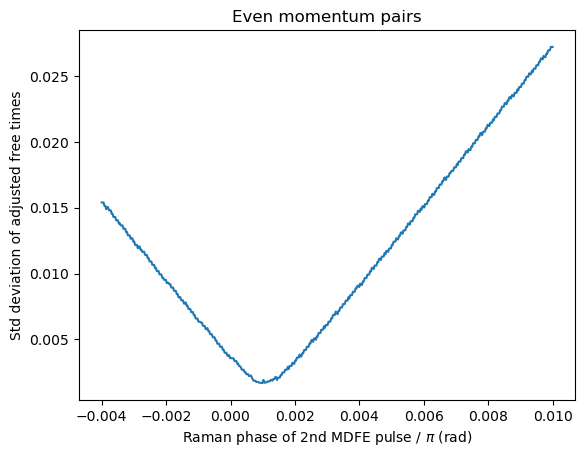

In [5]:
plt.plot(pulse2_phases/pi, stds_shifts)
plt.xlabel(r'Raman phase of 2nd MDFE pulse / $\pi$ (rad)')
plt.ylabel(r'Std deviation of adjusted free times')
plt.title('Even momentum pairs')
plt.show()

In [12]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

indices_list = [indices, indices2, indices3, indices4]



pulse2_phases = np.linspace(-pi,pi,100)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.9,1,100)
    phases = np.zeros((4, len(shifts)))

    for k, inds in enumerate(indices_list):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[inds[0]] = 1
        initial_state[inds[1]] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state)

        for i, shift in enumerate(shifts):
            duration = (pi/(4*dR))*shift

            mom_dependent_free_evolution = PulseSequence()

            down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


            mom_dependent_free_evolution.add_pulses([
                                                        down_pulse, freevolve, down_pulse2, freevolve,
                                                        ])


            wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

            phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.25))
    cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 1.25))
    cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 0.25))
    cross4 = np.argmin(np.abs(np.array(phases[3,:]) - 1.25))
    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.0
0.9515151515151515
-1.0


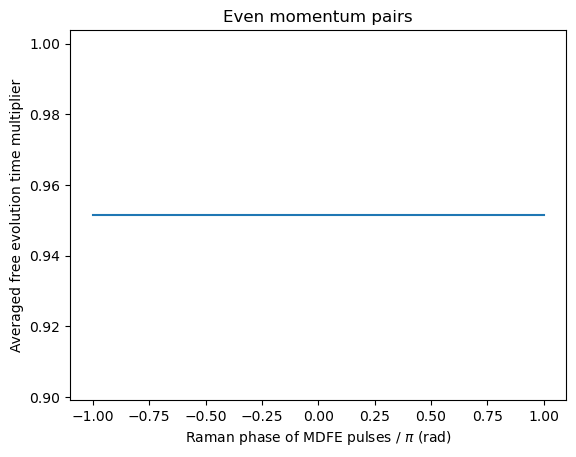

In [13]:
plt.plot(pulse2_phases/pi, avg_shifts)
plt.xlabel(r'Raman phase of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Averaged free evolution time multiplier')
plt.title('Even momentum pairs')
plt.show()